In [1]:
import sys, os
sys.path.insert(0, "/Users/abhinavarora/Desktop/CadenceCV/ml/src")
from models.footnet_model import CustomDataLoader, LSTM_custom
import torch
# configure_data only
from utils.obtain_metrics import configure_data
import pickle
import numpy as np
from torch.utils.data import DataLoader
from scipy import stats
import cv2

#Loading the model:
model = LSTM_custom(input_size=5, hidden_size=32, num_layers=1, num_classes=1)
model.load_state_dict(torch.load("/Users/abhinavarora/Desktop/CadenceCV/ml/weights/footnet_lstm_best.pth", weights_only=True))
model.eval()

LSTM_custom(
  (lstm): LSTM(5, 32, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [2]:
video_dir = '/Users/abhinavarora/Desktop/CadenceCV/Videos/Video17.mp4'
cache_path = "/Users/abhinavarora/Desktop/CadenceCV/ml/data/keypoints_cache.pkl"

# Load cached YOLO output if it exists, otherwise run compute_all_metrics once and save it.
# This avoids re-running YOLO every time you re-run this cell.
# Delete keypoints_cache.pkl whenever you switch to a different video.
if not os.path.exists(cache_path):
    from utils.obtain_metrics import compute_all_metrics
    print("No cache found — running YOLO inference...")
    frame_by_frame_data, frame_count, duration, right_hip_arr, left_hip_arr, right_ankle_arr, left_ankle_arr, right_knee_arr, left_knee_arr = compute_all_metrics(video_dir)
    with open(cache_path, "wb") as f:
        pickle.dump({
            "frame_by_frame_data": frame_by_frame_data,
            "frame_count": frame_count,
            "duration": duration,
            "right_hip_arr": right_hip_arr,
            "left_hip_arr": left_hip_arr,
        }, f)
    print(f"Cached to {cache_path}")
else:
    print(f"Loading cached YOLO output from {cache_path}")
    with open(cache_path, "rb") as f:
        cache = pickle.load(f)
    frame_by_frame_data = cache["frame_by_frame_data"]
    frame_count = cache["frame_count"]
    duration = cache["duration"]
    right_hip_arr = cache["right_hip_arr"]
    left_hip_arr = cache["left_hip_arr"]

Loading cached YOLO output from /Users/abhinavarora/Desktop/CadenceCV/ml/data/keypoints_cache.pkl


In [3]:
#Loading mean and std from pickle file
with open("/Users/abhinavarora/Desktop/CadenceCV/ml/weights/scaler_means_and_dev.pkl", "rb") as file:
    data = pickle.load(file)

means = data["Means"]
stds = data["Stds"]

#Running data through the CustomDataLoader
all_features, all_masks, all_frames, all_sides = configure_data(frame_by_frame_data, means, stds)
dataset = CustomDataLoader(all_features, all_masks)

batch_size = 32
#shuffle=False so batch i always maps to windows [i*batch_size, (i+1)*batch_size)
video_data = DataLoader(dataset, batch_size=batch_size, shuffle=False)

#Inference loop — storing unmasked predictions (shape: batch_size x 40) so the
#vote loop can index per-window using i * batch_size
all_predictions = []
with torch.no_grad():
    for (ind, data) in enumerate(video_data):
        features, masks = data
        logits = model(features)
        predictions = (torch.sigmoid(logits) > 0.5).long()
        all_predictions.append(predictions)

In [4]:
#Sliding window majority vote where each frame collects predictions from every window that covered it
#The predictions given by the LSTM are batched, meaning that each batch is of shape (32, 40) and not 
#(32, 40, 1) due to output.squeeze done in footnet_model. This corresponds to 32 chunks of size 40 frames (The resampling num)
#with a prediction attached to it. So, each batch must be iterated over where 32 chunks of size 40 are obtained.
#Instead of iterating over contiguous chunks, chunks in continguous batches are instead iterated over
frame_to_pred_dict = {}
for (i, batch_preds) in enumerate(all_predictions):
    #The first 40 frame window always will start at i * batch_size and the last 40 frame window will
    #be found at (i + 1) * batch_size
    window_start = i * batch_size
    #Last batch may not have 32 chunks
    batch_size_actual = batch_preds.shape[0]

    #Now this is iterating over the actual 40-sized framed windows
    for j in range(batch_size_actual):
        window_idx = window_start + j
        #Apply mask to get only real (non-padded) frames and predictions for this window
        window_mask = all_masks[window_idx]
        #applying the specific mask to a specific window in this current batch
        window_frames = all_frames[window_idx][window_mask]
        window_preds = batch_preds[j][window_mask]

        #Finally constructing the frame_to_pred_dict : {frame: predictions over each window}
        for (ind, frame) in enumerate(window_frames):
            frame_int = int(frame.item())
            if frame_int not in frame_to_pred_dict:
                frame_to_pred_dict[frame_int] = []
            frame_to_pred_dict[frame_int].append(window_preds[ind].item())

#Taking a majiority vote via mode
for frame in frame_to_pred_dict:
    frame_to_pred_dict[frame] = stats.mode(frame_to_pred_dict[frame], keepdims=True).mode[0]

print(frame_to_pred_dict)

#Detecting where strikefoot is actually happening
#Rising edge: first frame of each 0→1 transition in sorted frame order.
#np.diff on an unsorted dict gives wrong frame numbers — must iterate sorted keys.
strikefoot_frames = []
prev_pred = 0
for f in sorted(frame_to_pred_dict.keys()):
    curr_pred = frame_to_pred_dict[f]
    if curr_pred == 1 and prev_pred == 0:
        strikefoot_frames.append(f)
    prev_pred = curr_pred

{0: np.int64(1), 1: np.int64(1), 2: np.int64(1), 3: np.int64(1), 4: np.int64(1), 5: np.int64(1), 6: np.int64(1), 7: np.int64(1), 8: np.int64(1), 9: np.int64(1), 10: np.int64(1), 11: np.int64(1), 12: np.int64(1), 13: np.int64(1), 14: np.int64(1), 15: np.int64(1), 16: np.int64(1), 17: np.int64(1), 18: np.int64(1), 19: np.int64(1), 20: np.int64(1), 21: np.int64(1), 22: np.int64(1), 23: np.int64(1), 24: np.int64(1), 25: np.int64(1), 26: np.int64(1), 27: np.int64(1), 28: np.int64(1), 29: np.int64(1), 30: np.int64(1), 31: np.int64(1), 32: np.int64(1), 33: np.int64(1), 34: np.int64(1), 35: np.int64(1), 36: np.int64(0), 37: np.int64(1), 38: np.int64(1), 39: np.int64(1), 40: np.int64(1), 41: np.int64(1), 42: np.int64(1), 43: np.int64(1), 44: np.int64(1), 45: np.int64(1), 46: np.int64(1), 47: np.int64(1), 48: np.int64(1), 49: np.int64(1), 50: np.int64(1), 51: np.int64(1), 52: np.int64(1), 53: np.int64(1), 54: np.int64(1), 55: np.int64(1), 56: np.int64(1), 57: np.int64(1), 58: np.int64(1), 59: np


0: 640x512 1 person, 507.8ms
Speed: 1.7ms preprocess, 507.8ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 512)


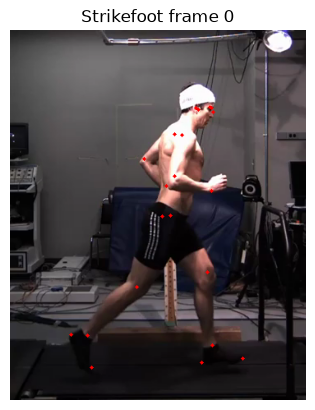


0: 640x512 1 person, 475.6ms
Speed: 1.2ms preprocess, 475.6ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


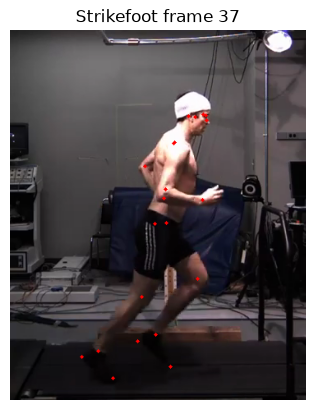


0: 640x512 1 person, 449.1ms
Speed: 1.1ms preprocess, 449.1ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 512)


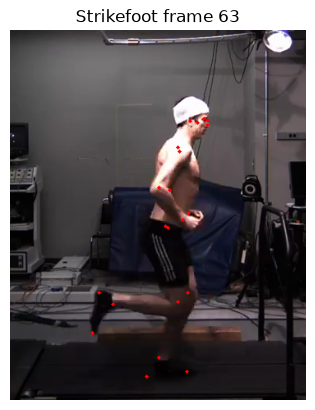


0: 640x512 1 person, 435.8ms
Speed: 1.1ms preprocess, 435.8ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 512)


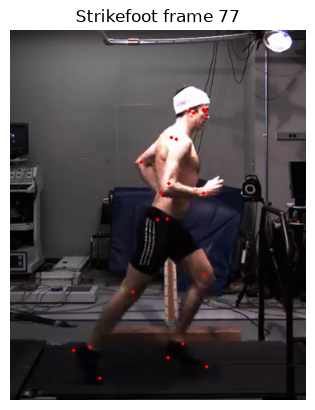


0: 640x512 1 person, 454.1ms
Speed: 1.2ms preprocess, 454.1ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


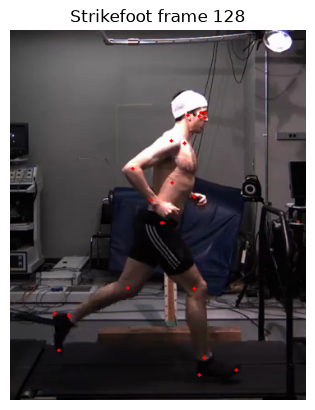


0: 640x512 1 person, 446.2ms
Speed: 1.3ms preprocess, 446.2ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


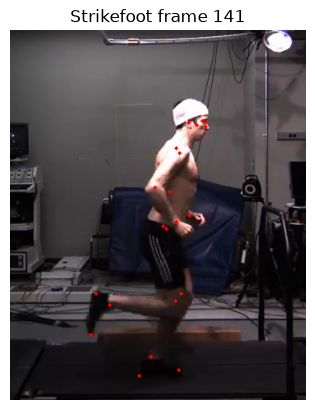


0: 640x512 1 person, 433.9ms
Speed: 1.3ms preprocess, 433.9ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


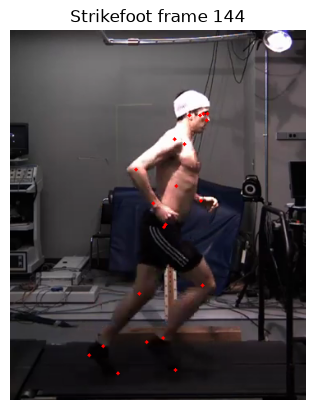


0: 640x512 1 person, 446.6ms
Speed: 1.4ms preprocess, 446.6ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


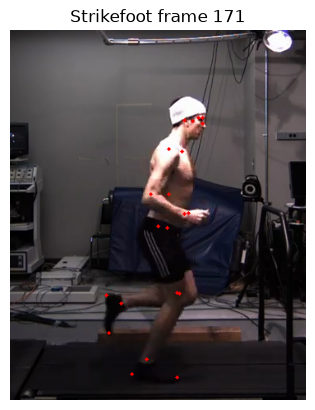


0: 640x512 1 person, 438.5ms
Speed: 1.2ms preprocess, 438.5ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


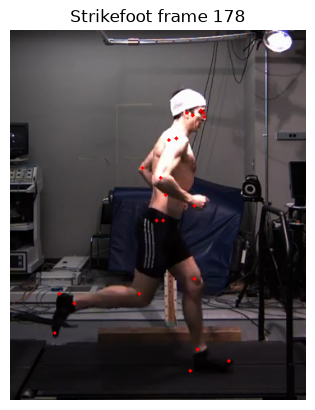


0: 640x512 1 person, 461.7ms
Speed: 1.1ms preprocess, 461.7ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


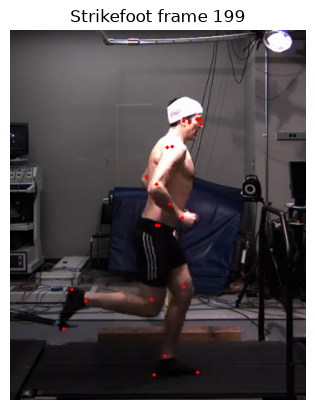


0: 640x512 1 person, 428.2ms
Speed: 1.2ms preprocess, 428.2ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


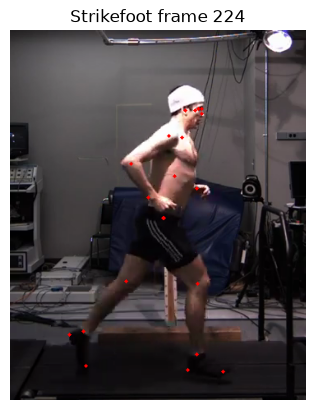


0: 640x512 1 person, 504.2ms
Speed: 1.2ms preprocess, 504.2ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


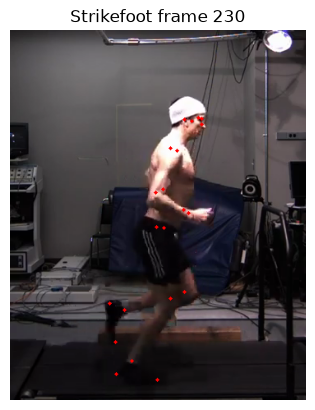


0: 640x512 1 person, 447.3ms
Speed: 1.1ms preprocess, 447.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


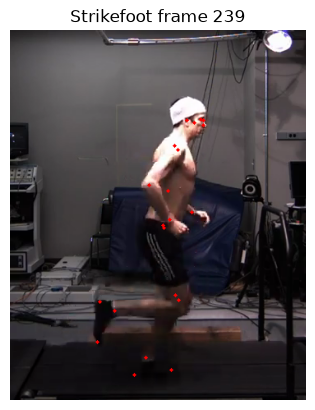


0: 640x512 1 person, 449.8ms
Speed: 1.1ms preprocess, 449.8ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)


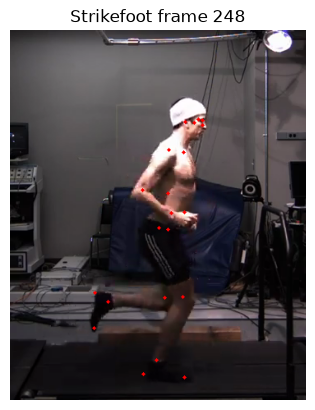

In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

viz_model = YOLO("/Users/abhinavarora/Desktop/CadenceCV/ml/weights/final_model.pt")
cap = cv2.VideoCapture(video_dir)
for f in strikefoot_frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(f))
    ret, img = cap.read()
    results = viz_model(img, stream=False, imgsz=640)
    for res in results:
        kpts = res.keypoints.xy[0]

    for point in kpts:
        p = point
        cv2.circle(img, tuple(p.int().tolist()), 2, (0,0,255), -1)

    #cv2 uses BGR, matplotlib expects RGB
    plt.figure()
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Strikefoot frame {f}')
    plt.axis('off') 
    plt.show()

cap.release()
cv2.destroyAllWindows()